In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

# ── Dataset 1: Mental Health in Tech ────────────────────────────
# Best model: Random Forest (CV Macro F1: 0.470, AUC: 0.696)
# Task: Multiclass classification (0, 1, 2)
# Using RF from baseline notebook — retrain here for SHAP

df_ml = pd.read_csv("../../data/processed/mental_health_tech_ml.csv")

# Reproduce exact preprocessing from baseline notebook
df = df_ml.copy()

if "work_interfere__missing" in df.columns:
    df = df[df["work_interfere__missing"] == 0].copy()
if "treatment__missing" in df.columns:
    df = df[df["treatment__missing"] == 0].copy()

df["work_interfere_binary"] = (
    df[["work_interfere_Rarely", "work_interfere_Sometimes", "work_interfere_Often"]]
    .sum(axis=1) > 0
).astype(int)

df["combined_target"] = np.select(
    [
        df["work_interfere_Never"] == 1,
        (df["work_interfere_binary"] == 1) & (df["treatment"] == 0),
        (df["work_interfere_binary"] == 1) & (df["treatment"] == 1),
    ],
    [0, 1, 2],
    default=np.nan
)

df = df.dropna(subset=["combined_target"]).copy()
df["combined_target"] = df["combined_target"].astype(int)

X = df.drop(columns=[
    "combined_target", "treatment",
    "work_interfere_Never", "work_interfere_Rarely",
    "work_interfere_Sometimes", "work_interfere_Often",
    "work_interfere__missing", "work_interfere_binary",
    "treatment__missing"
], errors="ignore")

REFERENCE_COLS = [
    "Gender_male", "no_employees_1-5", "benefits_No",
    "care_options_No", "wellness_program_No", "seek_help_No",
    "anonymity_No", "leave_Very difficult",
    "mental_health_consequence_No", "phys_health_consequence_No",
    "coworkers_No", "supervisor_No", "mental_health_interview_No",
    "phys_health_interview_No", "mental_vs_physical_No",
]
X = X.drop(columns=REFERENCE_COLS, errors="ignore")
y = df["combined_target"]

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (995, 43), y shape: (995,)


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_mhtech = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_mhtech.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [5]:
# SHAP for Random Forest — multiclass (new format)
explainer_mhtech = shap.TreeExplainer(rf_mhtech)

X_sample = X_test.sample(n=min(200, len(X_test)), random_state=42)

# shap_values shape: (n_samples, n_features, n_classes)
shap_values_mhtech = explainer_mhtech.shap_values(X_sample)

print(f"SHAP values shape: {shap_values_mhtech.shape}")
# Expected: (200, 43, 3)

# Split into per-class arrays to match old format
shap_class0 = shap_values_mhtech[:, :, 0]
shap_class1 = shap_values_mhtech[:, :, 1]
shap_class2 = shap_values_mhtech[:, :, 2]

print(f"Per-class shape: {shap_class0.shape}")
# Expected: (200, 43)

SHAP values shape: (199, 43, 3)
Per-class shape: (199, 43)


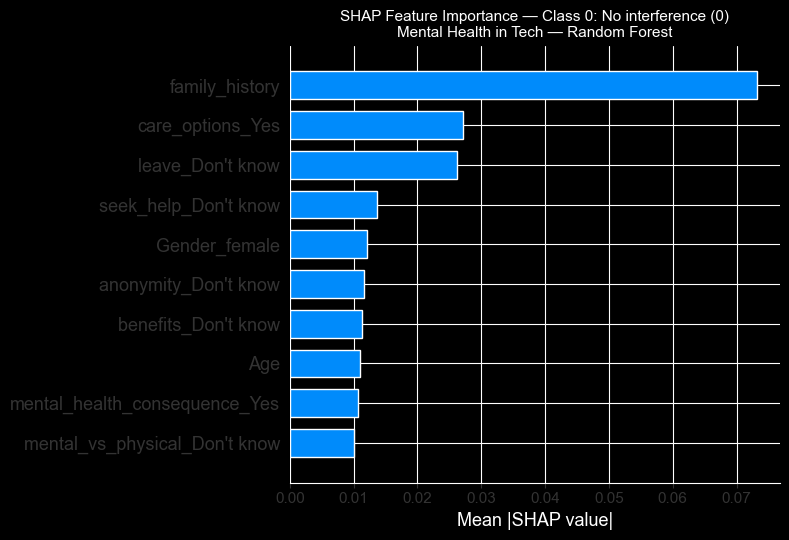

Saved: shap_mhtech_bar_class0.png


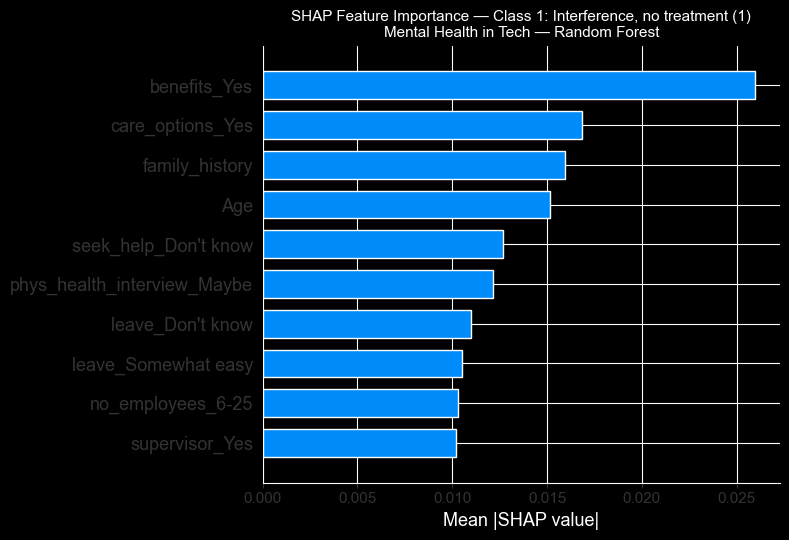

Saved: shap_mhtech_bar_class1.png


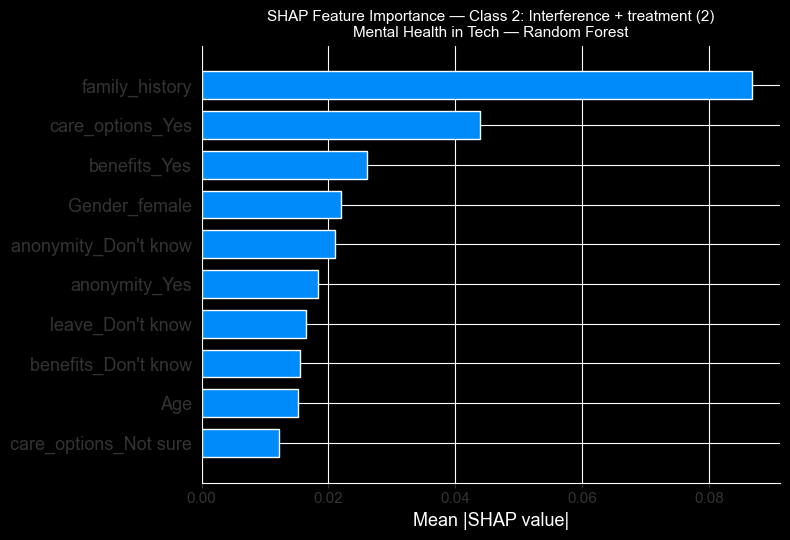

Saved: shap_mhtech_bar_class2.png


In [9]:
# Save three separate bar plots — one per class
class_names = [
    "No interference (0)",
    "Interference, no treatment (1)",
    "Interference + treatment (2)"
]

shap_per_class = [shap_class0, shap_class1, shap_class2]
filenames = [
    "shap_mhtech_bar_class0.png",
    "shap_mhtech_bar_class1.png",
    "shap_mhtech_bar_class2.png",
]

for i, (class_name, shap_vals, fname) in enumerate(
    zip(class_names, shap_per_class, filenames)
):
    plt.figure(figsize=(9, 6))
    shap.summary_plot(
        shap_vals,
        X_sample,
        plot_type="bar",
        max_display=10,
        show=False,
    )
    plt.title(
        f"SHAP Feature Importance — Class {i}: {class_name}\n"
        f"Mental Health in Tech — Random Forest",
        fontsize=11
    )
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.savefig(f"../../outputs/shap/{fname}", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

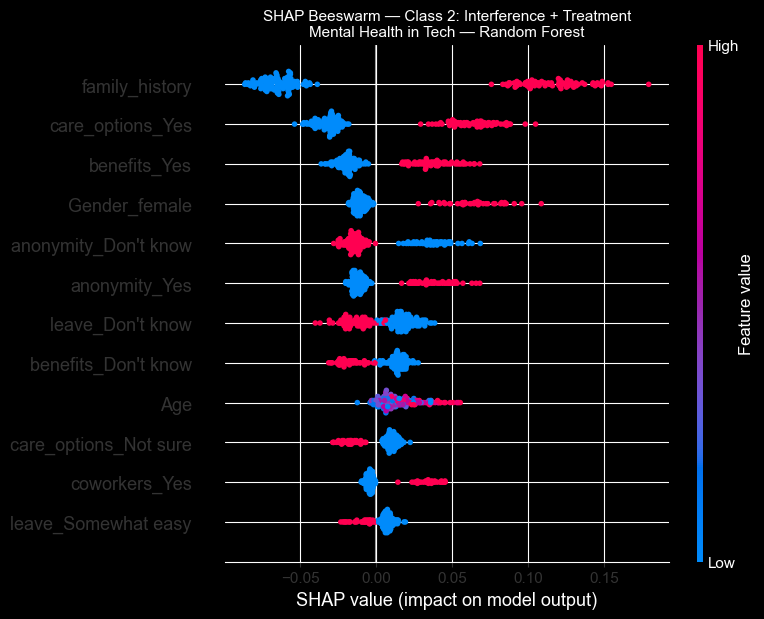

Saved.


In [10]:
# Beeswarm plot for Class 2 (interference + treatment)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_class2,
    X_sample,
    max_display=12,
    show=False
)
plt.title(
    "SHAP Beeswarm — Class 2: Interference + Treatment\n"
    "Mental Health in Tech — Random Forest",
    fontsize=11
)
plt.tight_layout()
plt.savefig("../../outputs/shap/shap_mhtech_beeswarm_class2.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [ ]:
# ### SHAP Analysis — Mental Health in Tech (Random Forest)
#
# SHAP analysis was applied to the Random Forest model to explain
# feature contributions across the three outcome classes.
#
# **Class 0 (No interference):** family_history dominates with a mean
# |SHAP| of ~0.073, followed distantly by care_options_Yes (~0.028)
# and leave_Don't know (~0.025). The model primarily uses family
# history as the signal for absence of interference, suggesting that
# respondents without a family history of mental illness are strongly
# predicted to report no work interference.
#
# **Class 1 (Interference, no treatment):** The feature pattern shifts
# substantially. benefits_Yes becomes the top predictor (~0.026),
# followed by care_options_Yes (~0.016) and family_history (~0.015).
# Notably, Age and seek_help_Don't know also appear, suggesting that
# younger respondents and those unaware of help-seeking resources are
# more likely to experience interference without seeking treatment.
# This class is the hardest to predict (F1: 0.37) and its SHAP profile
# is the most diffuse — no single feature dominates.
#
# **Class 2 (Interference + treatment):** family_history is by far
# the strongest predictor (mean |SHAP| ~0.090), more than double the
# next feature (care_options_Yes ~0.045). The beeswarm plot clarifies
# the direction: high family_history values (red dots) push strongly
# toward positive SHAP values, meaning a family history of mental
# illness substantially increases the probability of being classified
# as seeking treatment. Conversely, low family_history (blue dots)
# pushes toward negative SHAP values. care_options_Yes, benefits_Yes,
# and Gender_female all contribute positively, suggesting that
# respondents in supportive workplace environments who identify as
# female are more likely to seek treatment when experiencing
# interference.
#
# **Cross-class pattern:** family_history and care_options_Yes appear
# in the top features across all three classes, confirming their
# role as the most globally influential predictors in this dataset.
# This is consistent with permutation importance rankings from the
# baseline notebook and aligns with the psychological literature —
# genetic predisposition and perceived access to care are among the
# strongest predictors of mental health help-seeking behavior.
# The SHAP analysis adds directional information that feature
# importance alone cannot provide: high family_history pushes
# toward treatment-seeking (Class 2) and away from no-interference
# (Class 0), while uncertainty about care options (care_options_Not
# sure) pushes away from treatment-seeking.